In [236]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [237]:
df = pd.read_csv('sensor_readings_24.data', header = None)
df = df.rename(columns={24: 'Target'})
df.head()

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,Target
0,0.438,0.498,3.625,3.645,5.0,2.918,5.0,2.351,2.332,2.643,...,0.593,0.502,0.493,0.504,0.445,0.431,0.444,0.440,0.429,Slight-Right-Turn
1,0.438,0.498,3.625,3.648,5.0,2.918,5.0,2.637,2.332,2.649,...,0.592,0.502,0.493,0.504,0.449,0.431,0.444,0.443,0.429,Slight-Right-Turn
2,0.438,0.498,3.625,3.629,5.0,2.918,5.0,2.637,2.334,2.643,...,0.593,0.502,0.493,0.504,0.449,0.431,0.444,0.446,0.429,Slight-Right-Turn
3,0.437,0.501,3.625,3.626,5.0,2.918,5.0,2.353,2.334,2.642,...,0.593,0.502,0.493,0.504,0.449,0.431,0.444,0.444,0.429,Slight-Right-Turn
4,0.438,0.498,3.626,3.629,5.0,2.918,5.0,2.640,2.334,2.639,...,0.592,0.502,0.493,0.504,0.449,0.431,0.444,0.441,0.429,Slight-Right-Turn


In [238]:
df.isnull().sum()

0         0
1         0
2         0
3         0
4         0
5         0
6         0
7         0
8         0
9         0
10        0
11        0
12        0
13        0
14        0
15        0
16        0
17        0
18        0
19        0
20        0
21        0
22        0
23        0
Target    0
dtype: int64

In [239]:
df['Target'].value_counts(normalize=True).round(2)

Target
Move-Forward         0.40
Sharp-Right-Turn     0.38
Slight-Right-Turn    0.15
Slight-Left-Turn     0.06
Name: proportion, dtype: float64

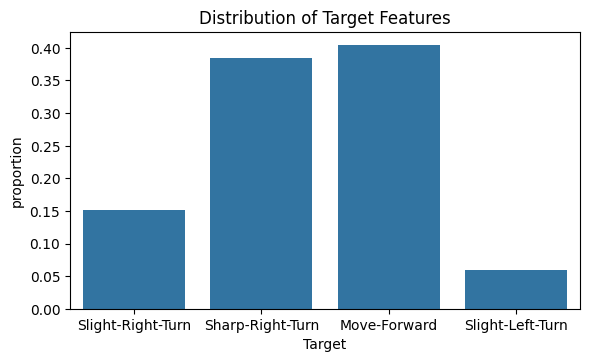

In [240]:
plt.figure(figsize=(6,3.5))
sns.countplot(x = df['Target'], stat = 'proportion' )
plt.tight_layout()
plt.title('Distribution of Target Features')
plt.show()

In [241]:
x = df.drop('Target', axis = 1)
y = df['Target']

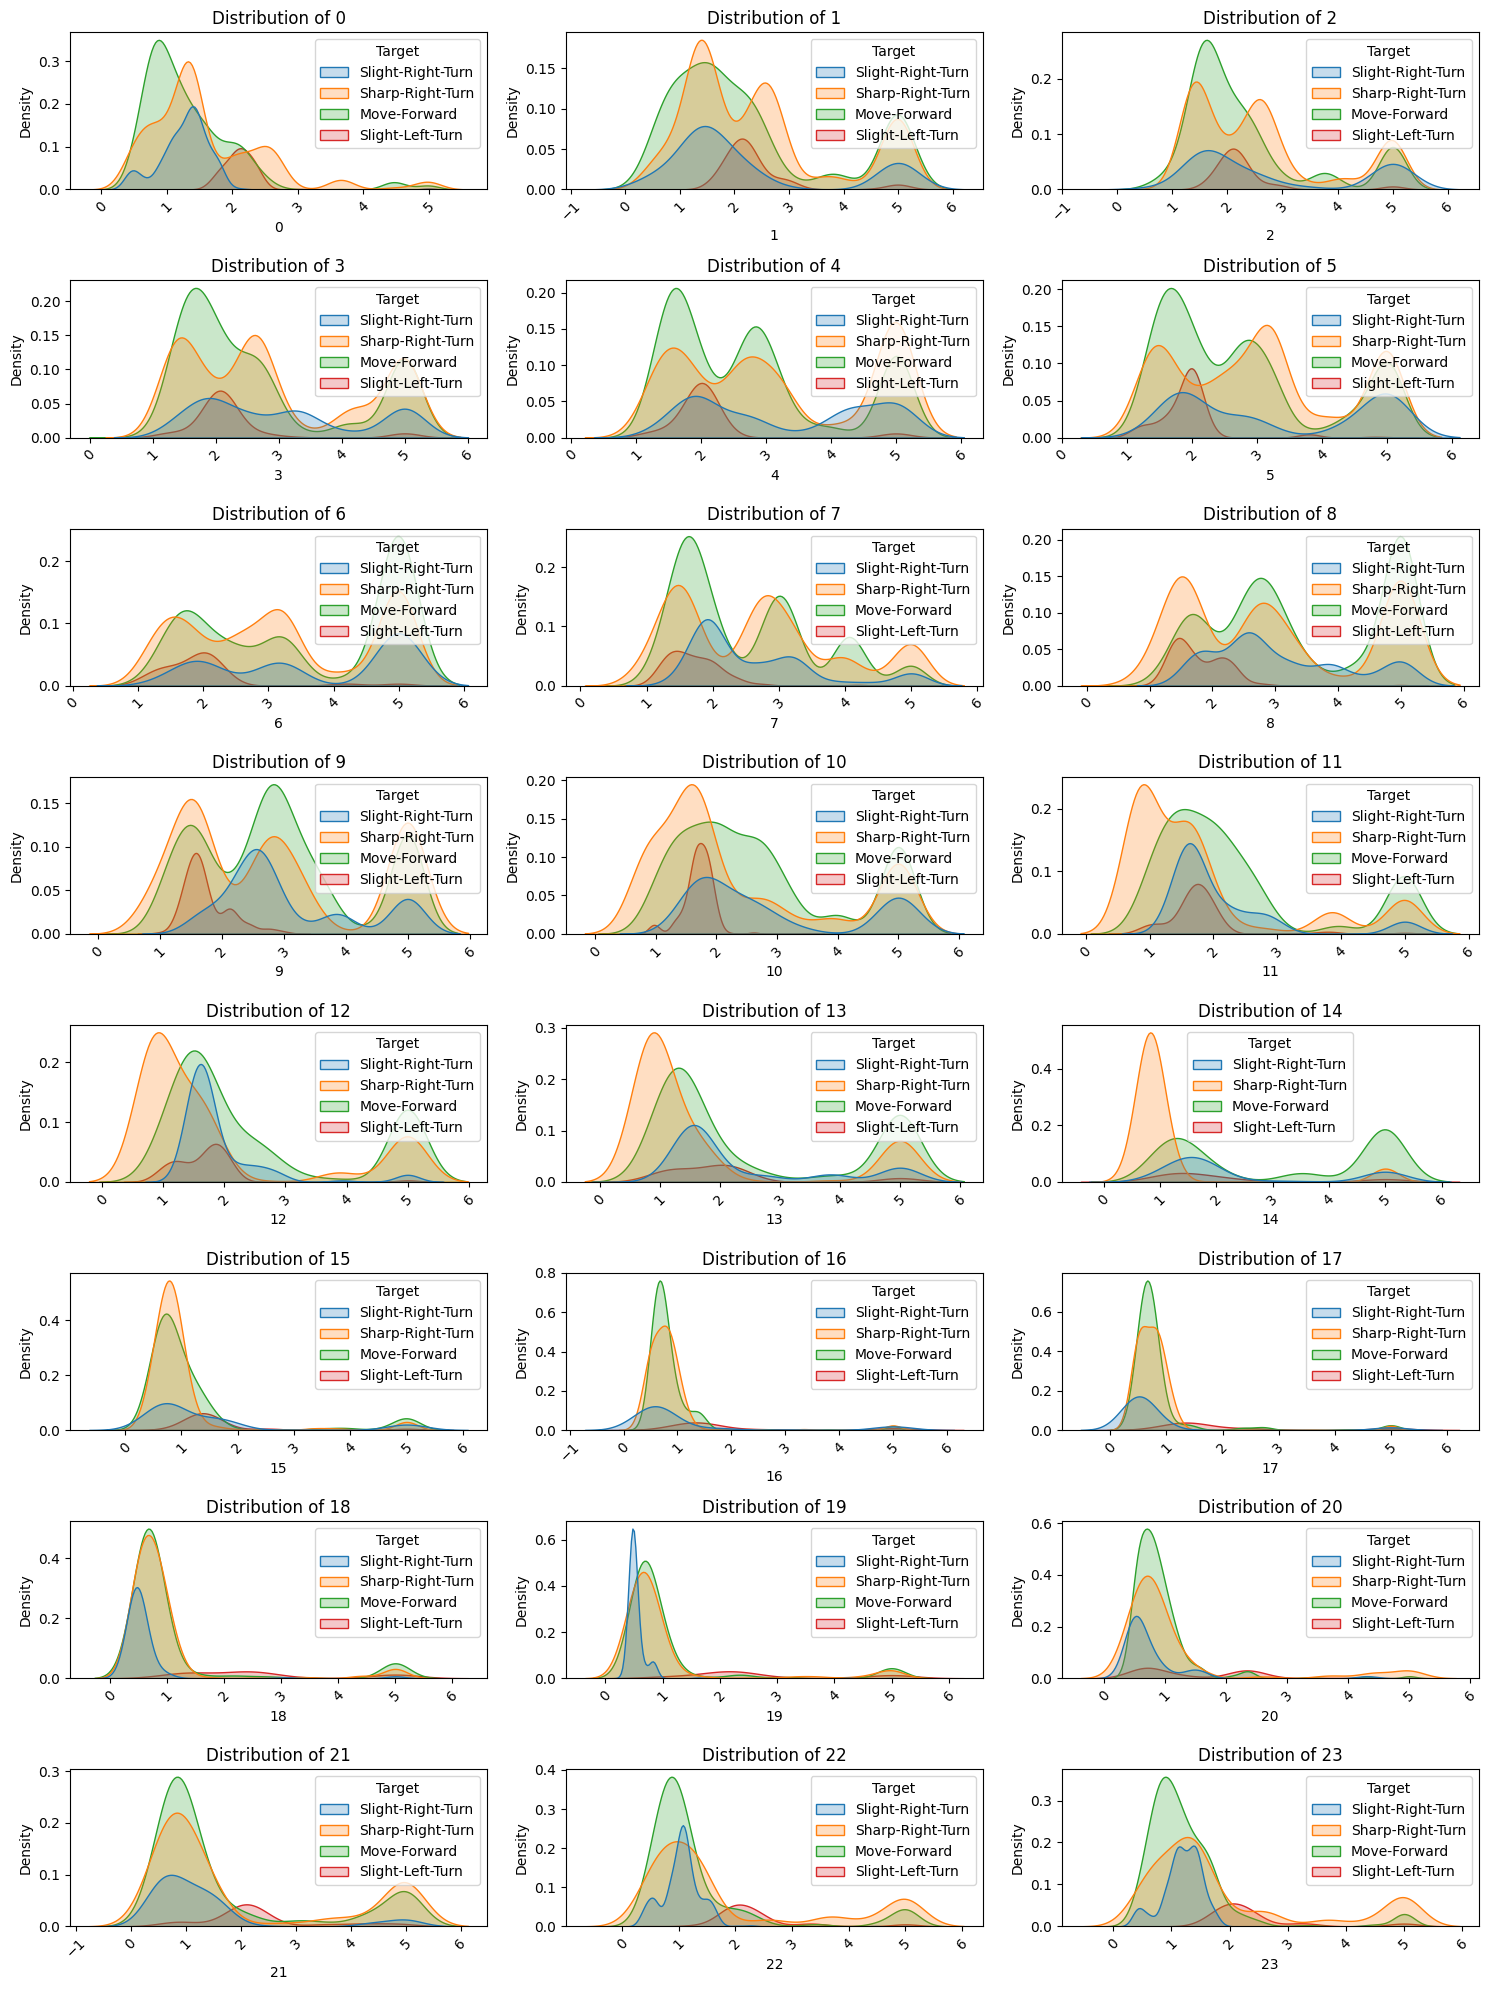

In [242]:
fig, axes = plt.subplots(nrows = 8, ncols= 3, figsize = (15,20))
axes = axes.flatten()

for i, col in enumerate(x):
    sns.kdeplot(data = df,
               x = df[col],
               hue = y,
               ax = axes[i],
               fill = True)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis = 'x', rotation = 45)

plt.tight_layout()
plt.show()

In [243]:
df.shape

(5456, 25)

In [244]:
x_model, x_test, y_model, y_test = train_test_split(x, y , 
                                                    test_size = 0.3,
                                                    random_state = 42,
                                                    shuffle = True,
                                                    stratify = y)

## Model Building

Since features are majorly not normally distributed ill use Mim max scaler 

In [245]:
x_model_sel = x.copy()
y_model_sel = y.copy()

scaler_model_sel = MinMaxScaler()
encoder_y_model_sel = LabelEncoder()

x_model_sel = scaler_model_sel.fit_transform(x_model_sel)
y_model_sel = encoder_y_model_sel.fit_transform(y_model_sel)

In [246]:
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state=42)

In [247]:
np.mean(cross_val_score(LogisticRegression(),
                        x_model_sel,
                        y_model_sel,
                        scoring = 'accuracy',
                        n_jobs = -1,
                        verbose = 0,
                        cv = cv))

np.float64(0.686586053726292)

In [248]:
np.mean(cross_val_score(DecisionTreeClassifier(),
                x_model_sel,
                y_model_sel,
                n_jobs = -1,
               verbose = 0,
                cv = cv))

np.float64(0.9954175522003202)

In [249]:
np.mean(cross_val_score(XGBClassifier(),
                x_model_sel,
                y_model_sel,
                n_jobs = -1,
               verbose = 0,
                cv = cv))

np.float64(0.9972503970212493)

In [250]:
np.mean(cross_val_score(LGBMClassifier(),
                x_model_sel,
                y_model_sel,
                n_jobs = -1,
               verbose = 0,
                cv = cv))

np.float64(0.9972505648949278)

## Model building

In [251]:
encoder = LabelEncoder()
y_model = encoder.fit_transform(y_model)
y_test = encoder.transform(y_test)

In [252]:
oof_pred = np.zeros(len(x_model))
test_pred = np.zeros((len(x_test), 4))
fold_pred = []

fold_cv = StratifiedKFold(random_state=42, n_splits = 5, shuffle = True)

for fold, (train_idx, val_idx) in enumerate(fold_cv.split(x_model, y_model)):
    x_train, x_val = x_model.iloc[train_idx].copy(), x_model.iloc[val_idx].copy()
    y_train, y_val = y_model[train_idx], y_model[val_idx]

    x_test_mod = x_test.copy()

    scaler = MinMaxScaler()
    x_train = scaler.fit_transform(x_train)
    x_val = scaler.transform(x_val)
    x_test_mod = scaler.transform(x_test_mod)

    model = LGBMClassifier(eval_metric = 'accuracy',
                          verbose = 0)
    model.fit(x_train, y_train)

    val_pred = model.predict(x_val)
    oof_pred[val_idx] = val_pred

    fold_score = accuracy_score(y_val, val_pred)
    fold_pred.append(fold_score)

    test_pred += model.predict_proba(x_test_mod)/ fold_cv.n_splits
    print(f'Fold: {fold + 1}: {fold_score:.4f} ')

oof_score = accuracy_score(y_model, oof_pred)
print(f'Accuracy_score: {oof_score}')

[LightGBM] [Warning] Unknown parameter: eval_metric
[LightGBM] [Warning] Unknown parameter: eval_metric
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

C:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

C:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

C:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

C:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

C:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [253]:
test_pred = np.argmax(test_pred, axis = 1)
test_pred_label = encoder.inverse_transform(test_pred)
y_test_label = encoder.inverse_transform(y_test)

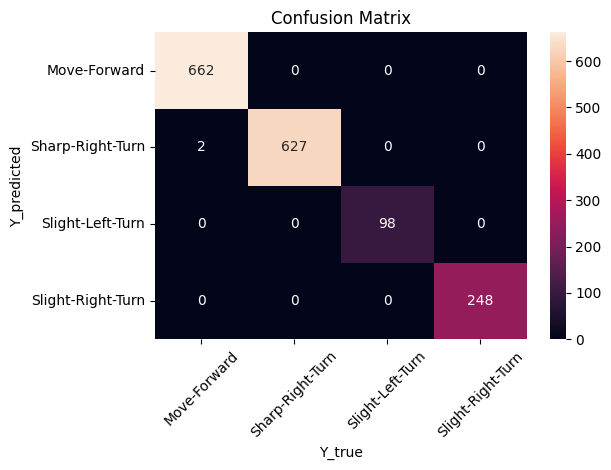

In [264]:
cm = confusion_matrix(y_test_label, test_pred_label)
sns.heatmap(cm, annot = True,
            fmt='.0f',
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Y_true')
plt.ylabel('Y_predicted')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

In [255]:
print(classification_report(y_test_label, test_pred_label))

                   precision    recall  f1-score   support

     Move-Forward       1.00      1.00      1.00       662
 Sharp-Right-Turn       1.00      1.00      1.00       629
 Slight-Left-Turn       1.00      1.00      1.00        98
Slight-Right-Turn       1.00      1.00      1.00       248

         accuracy                           1.00      1637
        macro avg       1.00      1.00      1.00      1637
     weighted avg       1.00      1.00      1.00      1637

